In [1]:
from math import sqrt
import numpy as np
import pandas as pd
import pickle
import seaborn as sns
import scipy as sp
import scipy.sparse as scs
import matplotlib
import matplotlib.pyplot as plt
from numpy.linalg import svd
from sklearn.manifold import TSNE
from sklearn.metrics import r2_score
from sklearn.preprocessing import LabelEncoder
from tqdm.notebook import tqdm

In [23]:
df = pd.read_csv('df_electronics.csv')
df.head()

,item_id,user_id,rating,timestamp,model_attr,category,brand,year,user_attr,split
0,0,0,5.0,1999-06-13,Female,Portable Audio & Video,NaN,1999,NaN,0
1,0,1,5.0,1999-06-14,Female,Portable Audio & Video,NaN,1999,NaN,0
2,0,2,3.0,1999-06-17,Female,Portable Audio & Video,NaN,1999,NaN,0
3,0,3,1.0,1999-07-01,Female,Portable Audio & Video,NaN,1999,NaN,0
4,0,4,2.0,1999-07-06,Female,Portable Audio & Video,NaN,1999,NaN,0


### Анализ данных

In [3]:
df.shape

(1292954, 10)

In [4]:
df.category.value_counts()

category
Headphones                 359334
Computers & Accessories    322938
Camera & Photo             192573
Accessories & Supplies     158598
Portable Audio & Video     143370
Car Electronics & GPS       33070
Television & Video          32057
Home Audio                  24193
Wearable Technology         16015
Security & Surveillance     10806
Name: count, dtype: int64

In [5]:
missing_values = df.isnull().sum()
missing_values

item_id             0
user_id             0
rating              0
timestamp           0
model_attr          0
category            0
brand          961834
year                0
user_attr     1118830
split               0
dtype: int64

процент пропусков

In [6]:
missing_percentage = (missing_values / len(df)) * 100
missing_percentage

item_id        0.000000
user_id        0.000000
rating         0.000000
timestamp      0.000000
model_attr     0.000000
category       0.000000
brand         74.390427
year           0.000000
user_attr     86.532854
split          0.000000
dtype: float64

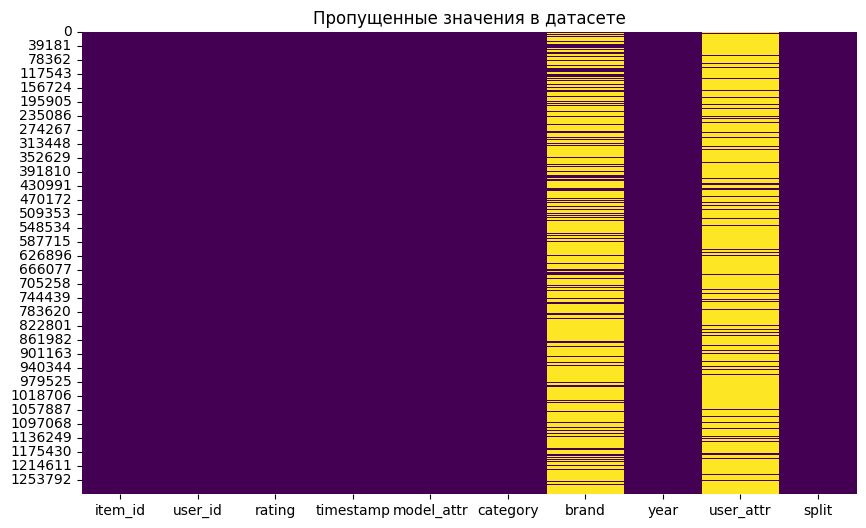

In [7]:
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Пропущенные значения в датасете')
plt.show()

In [8]:
df['brand'] = df['brand'].fillna('Unknown')
df['brand'].value_counts()

brand
Unknown         961834
Bose             29222
Logitech         29203
Sony             20360
Mpow             17477
EldHus           16530
Sennheiser       13322
Fujifilm         12245
TaoTronics       12125
Etre Jeune       11753
Pyle             11606
JLAB             10079
Skullcandy       10014
Kodak             8701
Linksys           8288
Jabra             7417
Panasonic         7349
Fintie            7212
Garmin            7212
Samsung           7051
Canon             6959
Neewer            6697
Philips           6658
Nikon             6539
Apple             6027
Polaroid          5926
DBPOWER           4818
Uniden            4701
Olympus           3709
ViewSonic         3426
ebasy             2771
Plemo             2385
HP                2140
LSS               2040
Toshiba           2008
Savage            1749
Tiamat            1738
XShields          1709
JVC               1702
Generic           1606
Gary Fong         1203
iRULU              991
Archos             961
Funlu

C:\Users\User\AppData\Local\Temp\ipykernel_10176\343519405.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_brands.values, y=top_brands.index, palette='viridis')


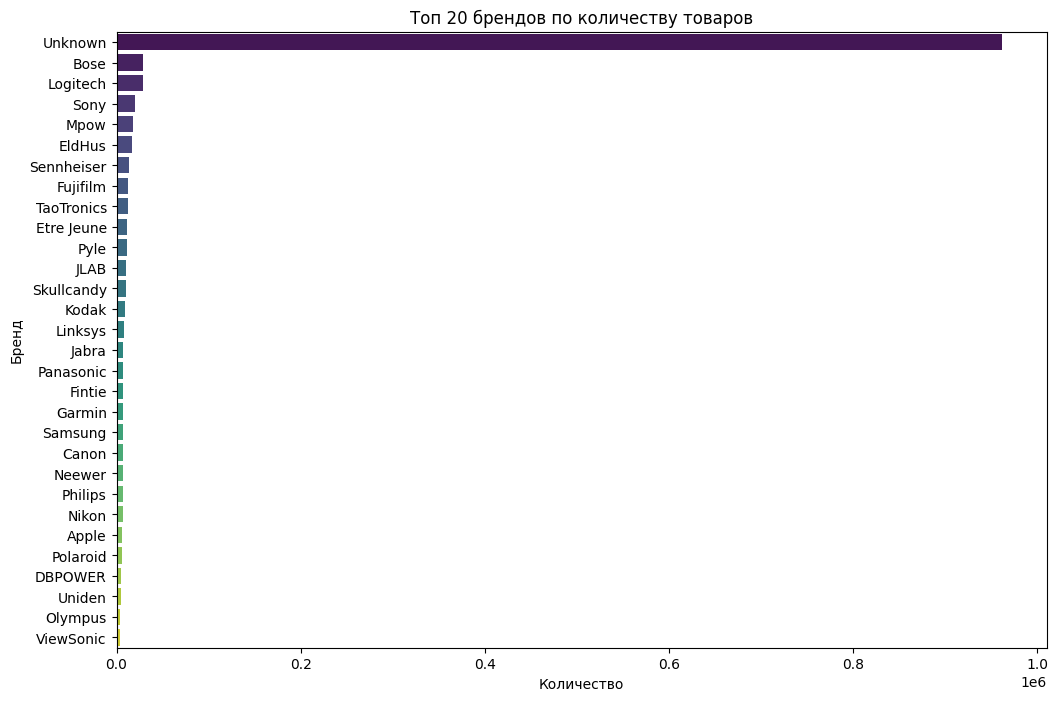

In [9]:
plt.figure(figsize=(12,8))
top_brands = df['brand'].value_counts().head(30)
sns.barplot(x=top_brands.values, y=top_brands.index, palette='viridis')
plt.title('Топ 20 брендов по количеству товаров')
plt.xlabel('Количество')
plt.ylabel('Бренд')
plt.show()

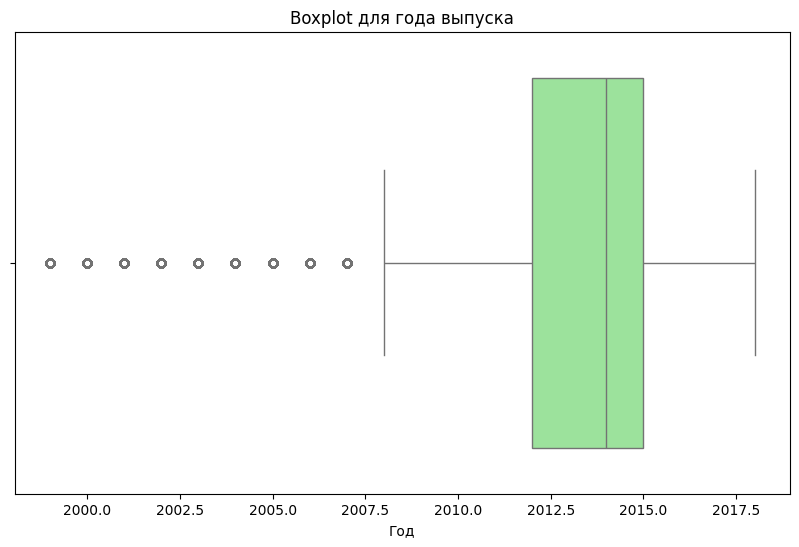

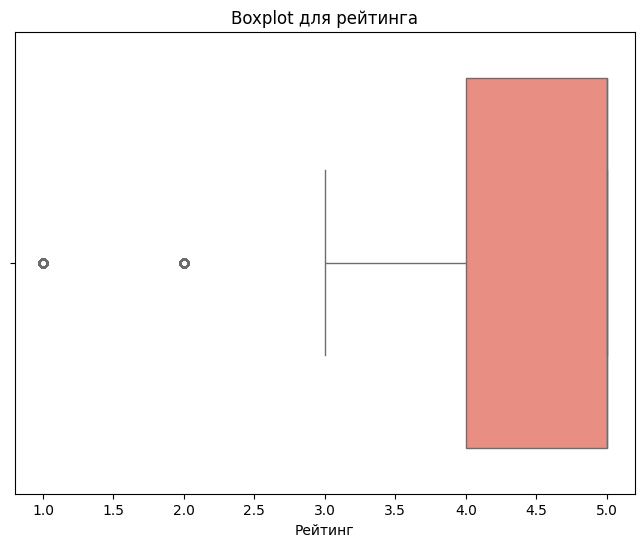

In [11]:
plt.figure(figsize=(10,6))
sns.boxplot(x=df['year'], color='lightgreen')
plt.title('Boxplot для года выпуска')
plt.xlabel('Год')
plt.show()

plt.figure(figsize=(8,6))
sns.boxplot(x=df['rating'], color='salmon')
plt.title('Boxplot для рейтинга')
plt.xlabel('Рейтинг')
plt.show()


In [12]:
df.model_attr.value_counts()

model_attr
Female         481171
Male           429715
Female&Male    382068
Name: count, dtype: int64

C:\Users\User\AppData\Local\Temp\ipykernel_8880\51721959.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='model_attr', data=df, palette='coolwarm')


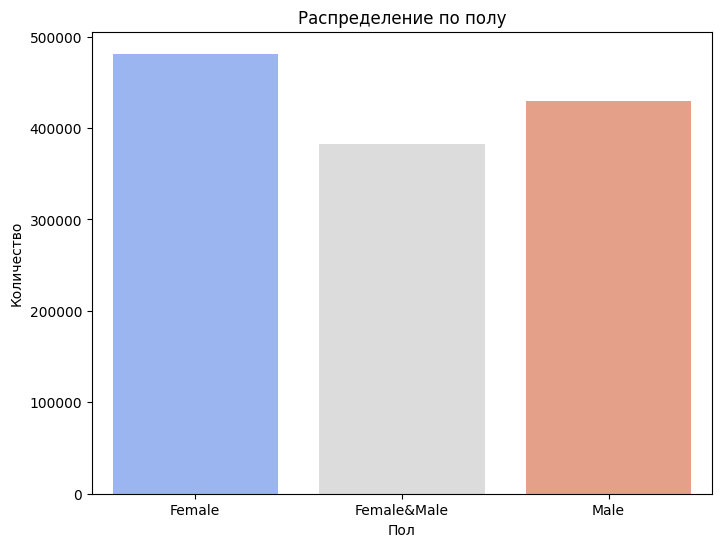

In [22]:
plt.figure(figsize=(8,6))
sns.countplot(x='model_attr', data=df, palette='coolwarm')
plt.title('Распределение по полу')
plt.xlabel('Пол')
plt.ylabel('Количество')
plt.show()

Влияние пола на рейтинг

C:\Users\User\AppData\Local\Temp\ipykernel_8880\387558935.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_attr_rating.values, y=model_attr_rating.index, palette='viridis')


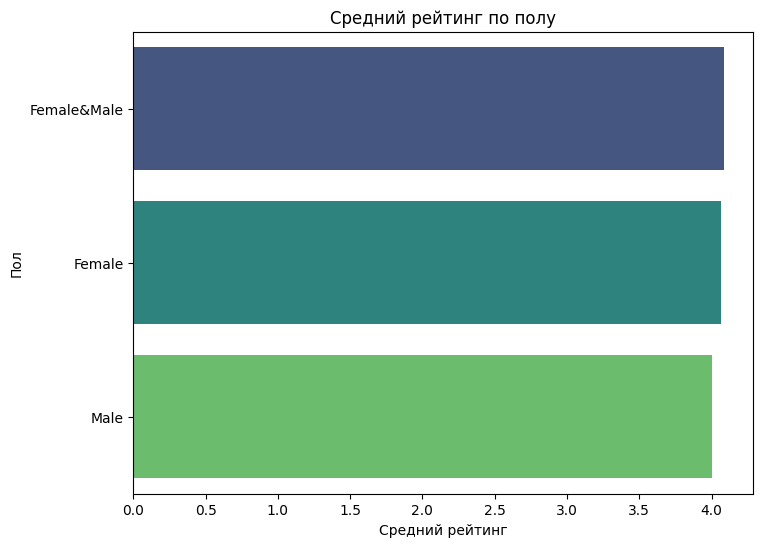

In [24]:
# средний рейтинг
model_attr_rating = df.groupby('model_attr')['rating'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x=model_attr_rating.values, y=model_attr_rating.index, palette='viridis')
plt.title('Средний рейтинг по полу')
plt.xlabel('Средний рейтинг')
plt.ylabel('Пол')
plt.show()


## Категории

C:\Users\User\AppData\Local\Temp\ipykernel_8880\2029779825.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_rating.values, y=category_rating.index, palette='magma')


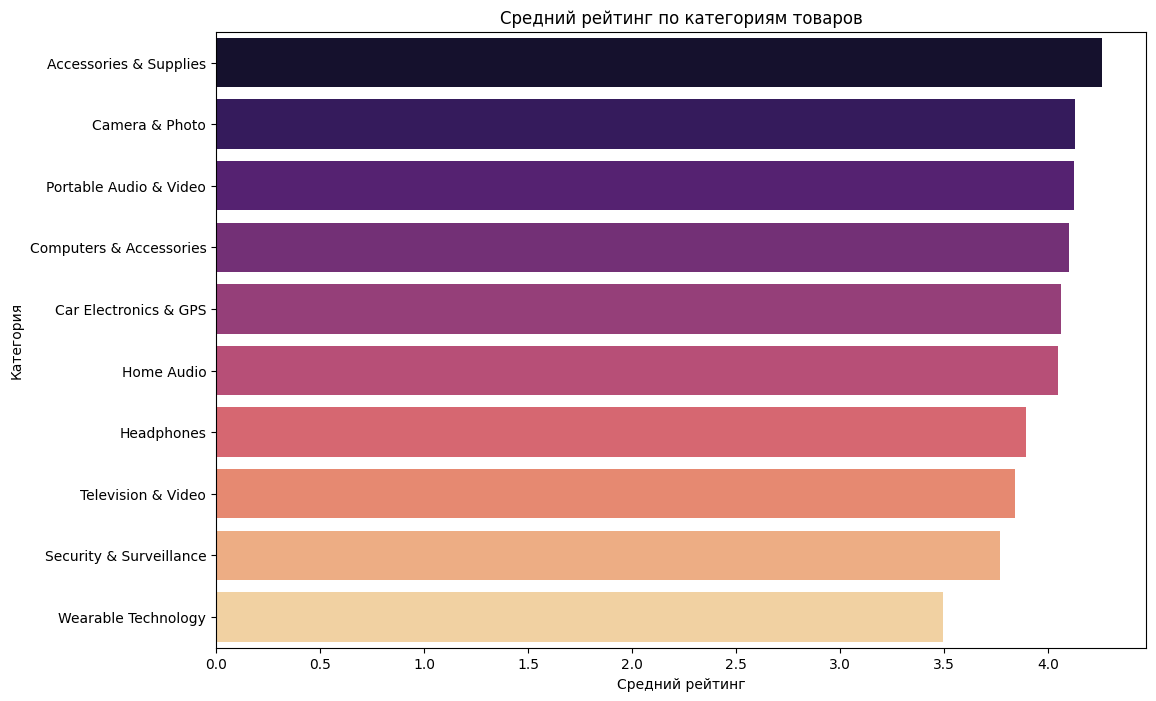

In [25]:
category_rating = df.groupby('category')['rating'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,8))
sns.barplot(x=category_rating.values, y=category_rating.index, palette='magma')
plt.title('Средний рейтинг по категориям товаров')
plt.xlabel('Средний рейтинг')
plt.ylabel('Категория')
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_8880\3301574666.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=brand_mean_rating.values, y=brand_mean_rating.index, palette='viridis')


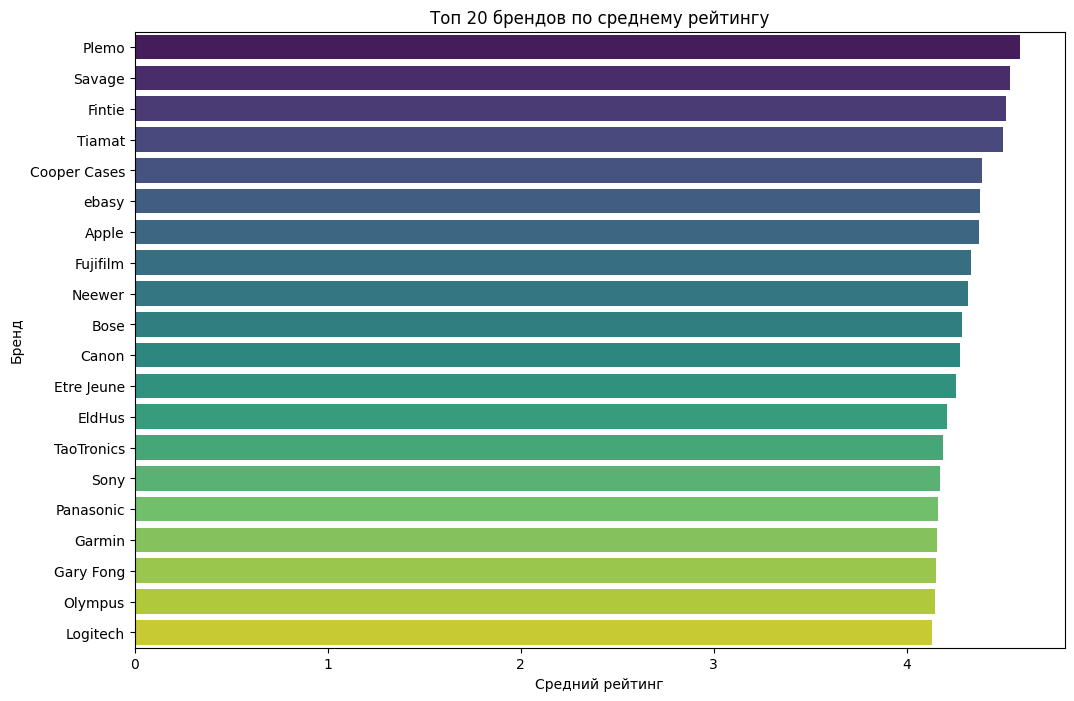

In [26]:
# Средний рейтинг по брендам 
brand_mean_rating = df.groupby('brand')['rating'].mean().sort_values(ascending=False).head(20)

plt.figure(figsize=(12,8))
sns.barplot(x=brand_mean_rating.values, y=brand_mean_rating.index, palette='viridis')
plt.title('Топ 20 брендов по среднему рейтингу')
plt.xlabel('Средний рейтинг')
plt.ylabel('Бренд')
plt.show()


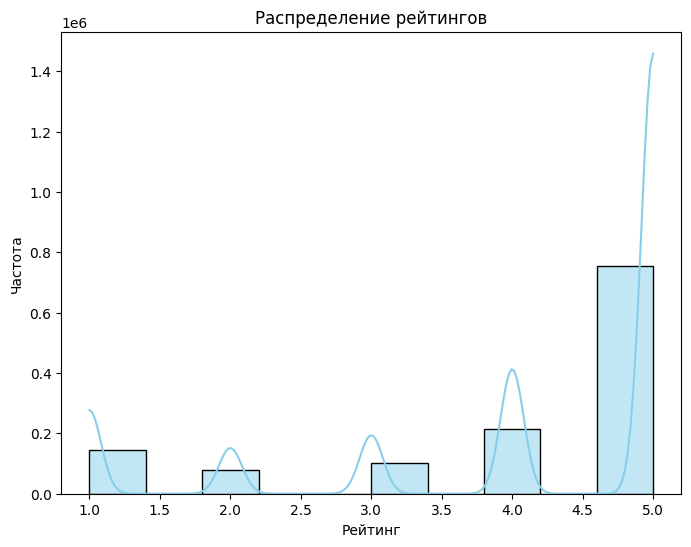

In [13]:
plt.figure(figsize=(8,6))
sns.histplot(df['rating'], bins=10, kde=True, color='skyblue')
plt.title('Распределение рейтингов')
plt.xlabel('Рейтинг')
plt.ylabel('Частота')
plt.show()

Выпуск товара по годам

C:\Users\User\AppData\Local\Temp\ipykernel_10176\2953905292.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='year', data=df, palette='viridis')


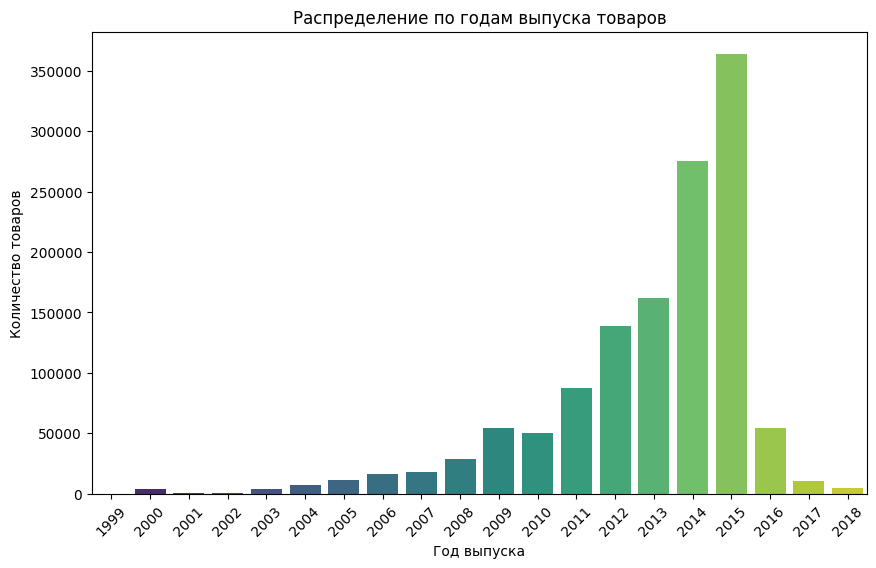

In [14]:
plt.figure(figsize=(10,6))
sns.countplot(x='year', data=df, palette='viridis')
plt.title('Распределение по годам выпуска товаров')
plt.xlabel('Год выпуска')
plt.ylabel('Количество товаров')
plt.xticks(rotation=45)
plt.show()

In [30]:
df['last_watch_dt'] = (pd.to_datetime(df['timestamp']) - pd.to_datetime(df['timestamp']).min())
df['last_watch_dt'] = df.last_watch_dt.apply(lambda x: int(str(x).split()[0]))

<Axes: >

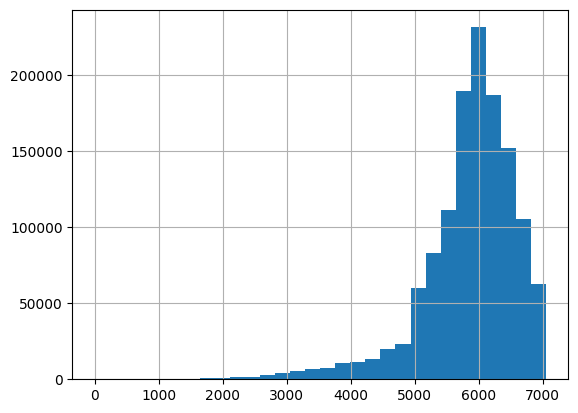

In [31]:
df.last_watch_dt.hist(bins=30)

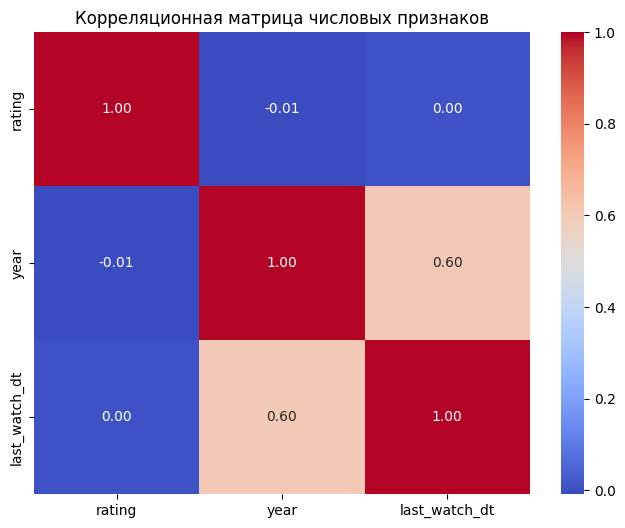

In [33]:
numerical_features = ['rating', 'year', 'last_watch_dt']

corr_matrix = df[numerical_features].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Корреляционная матрица числовых признаков')
plt.show()


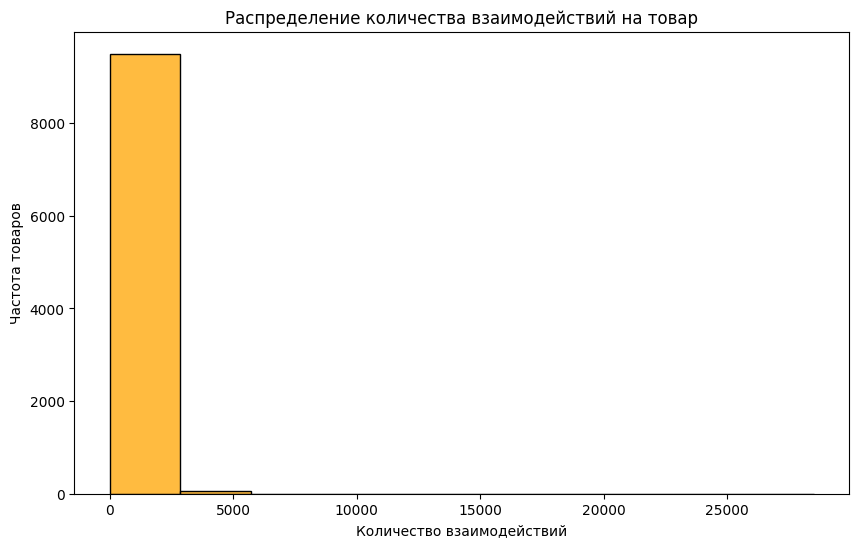

In [42]:
plt.figure(figsize=(10,6))
sns.histplot(df['item_id'].value_counts(), bins=10, color='orange')
plt.title('Распределение количества взаимодействий на товар')
plt.xlabel('Количество взаимодействий')
plt.ylabel('Частота товаров')
plt.show()


In [45]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['year_interaction'] = df['timestamp'].dt.year
df['month_interaction'] = df['timestamp'].dt.month
df['day_of_week'] = df['timestamp'].dt.dayofweek  

C:\Users\User\AppData\Local\Temp\ipykernel_10176\724220867.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='month_interaction', data=df, palette='coolwarm')


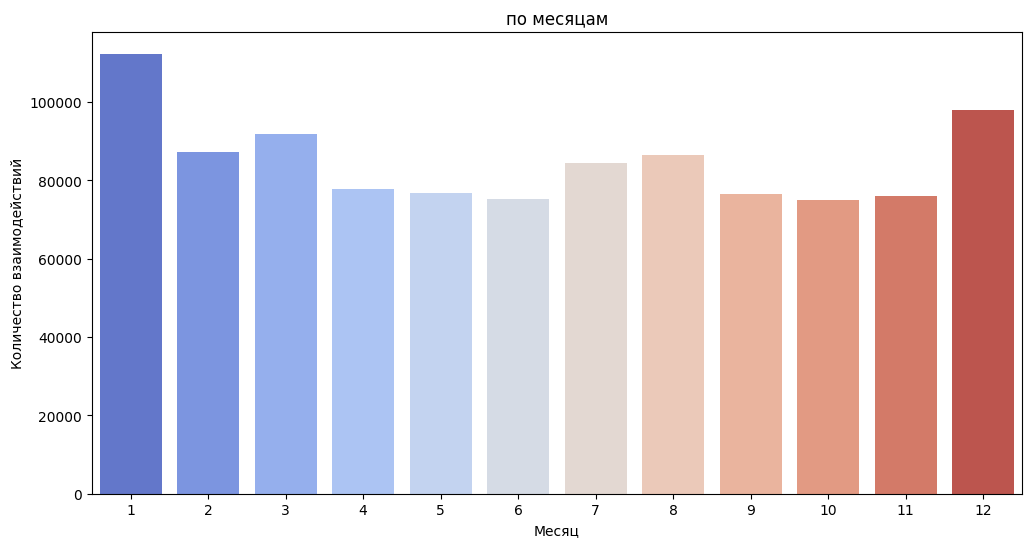

In [41]:
plt.figure(figsize=(12, 6))
sns.countplot(x='month_interaction', data=df, palette='coolwarm')
plt.title('по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Количество взаимодействий')
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_10176\2573892255.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='day_of_week_name', data=df, palette='Set2', order=days)


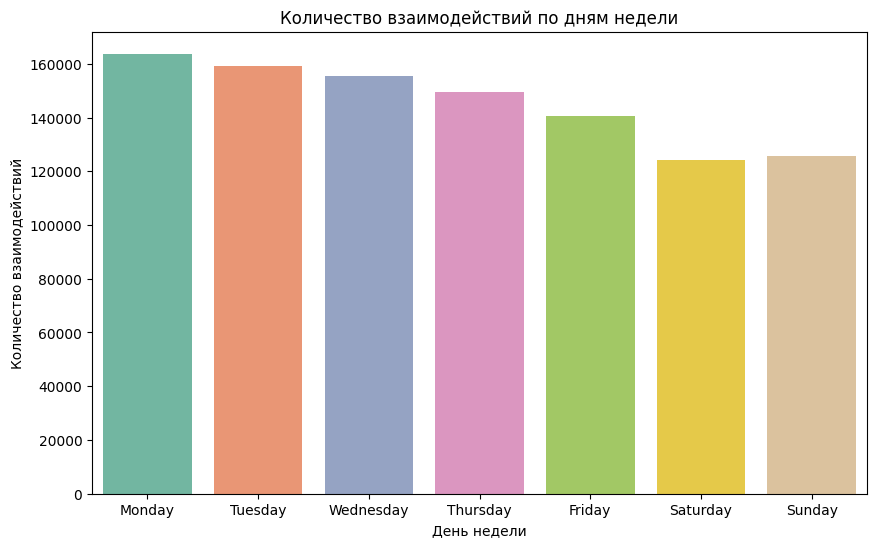

In [42]:
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['day_of_week_name'] = df['day_of_week'].apply(lambda x: days[x])

plt.figure(figsize=(10, 6))
sns.countplot(x='day_of_week_name', data=df, palette='Set2', order=days)
plt.title('Количество взаимодействий по дням недели')
plt.xlabel('День недели')
plt.ylabel('Количество взаимодействий')
plt.show()


Тепловая таблица

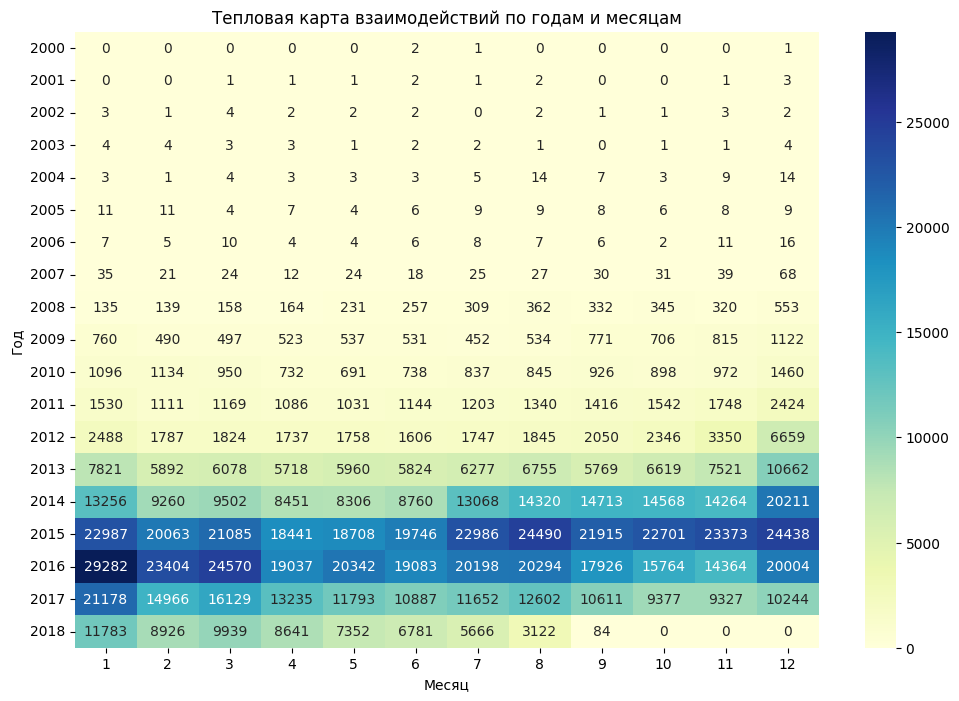

In [46]:
interaction_pivot = df.pivot_table(index='year_interaction', columns='month_interaction', values='item_id', aggfunc='count', fill_value=0)

plt.figure(figsize=(12, 8))
sns.heatmap(interaction_pivot, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Тепловая карта взаимодействий по годам и месяцам')
plt.xlabel('Месяц')
plt.ylabel('Год')
plt.show()

In [59]:
df['day_of_month'] = df['timestamp'].dt.day

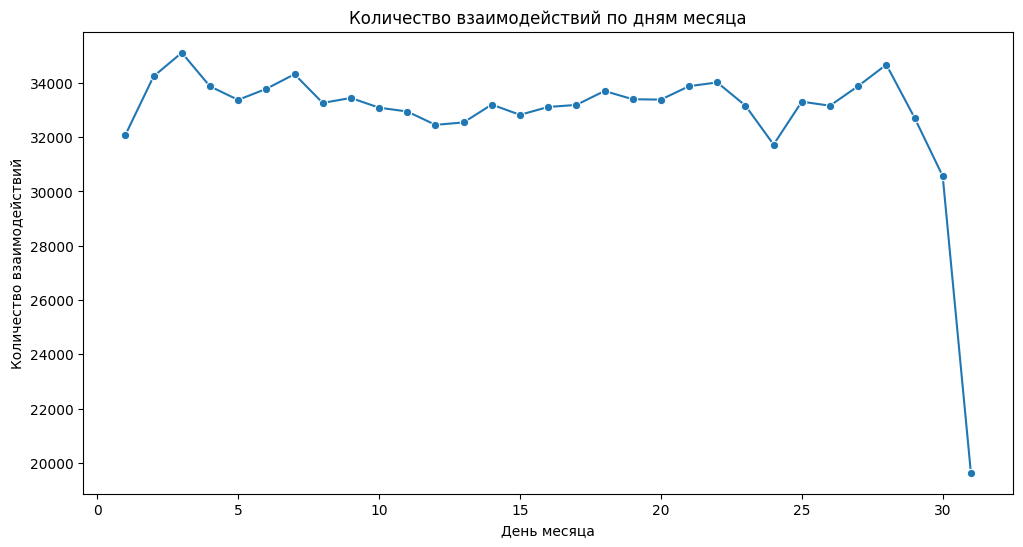

In [60]:
daily_sales = df.groupby('day_of_month')['item_id'].count().reset_index()
daily_sales.rename(columns={'item_id': 'sales'}, inplace=True)

plt.figure(figsize=(12,6))
sns.lineplot(x='day_of_month', y='sales', data=daily_sales, marker='o')
plt.title('Количество взаимодействий по дням месяца')
plt.xlabel('День месяца')
plt.ylabel('Количество взаимодействий')
plt.show()


# Чистка + фичи

In [47]:
df = df[(df['year'] >= 2008)].copy()
pupu_date = pd.Timestamp('2018-08-31')
df = df[df['timestamp'] <= pupu_date].copy()

In [26]:
df = df.drop(columns=['user_attr'])

По времени 

In [51]:
holiday_months = [12]
df['is_holiday_month'] = df['month_interaction'].apply(lambda x: 1 if x in holiday_months else 0)

колво дней с последнего заказа

In [52]:
df = df.sort_values(['user_id', 'timestamp'])
df['days_since_last_interaction'] = df.groupby('user_id')['timestamp'].diff().dt.days
df['days_since_last_interaction'] = df['days_since_last_interaction'].fillna(df['days_since_last_interaction'].median())

Активность пользователя по годам

In [53]:
user_yearly_interactions = df.groupby(['user_id', 'year_interaction']).size().unstack(fill_value=0)
user_yearly_interactions['interaction_trend'] = user_yearly_interactions.iloc[:, -1] - user_yearly_interactions.iloc[:, 0]
df = df.merge(user_yearly_interactions[['interaction_trend']], on='user_id', how='left')

### Надо проверять качество

Пропуски брендов заполняем наиболее частыми брендами в каждой категории

In [18]:
df['brand'] = df['brand'].fillna('Unknown')

In [27]:
def fill_brand(row):
    if pd.isnull(row['brand']):
        return mode_brand_per_category.get(row['category'], 'Unknown')
    else:
        return row['brand']

mode_brand_per_category = df.groupby('category')['brand'].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else 'Unknown').to_dict()

df['brand'] = df.apply(fill_brand, axis=1)

C:\Users\User\AppData\Local\Temp\ipykernel_10176\3783677616.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_brands.values, y=top_brands.index, palette='viridis')


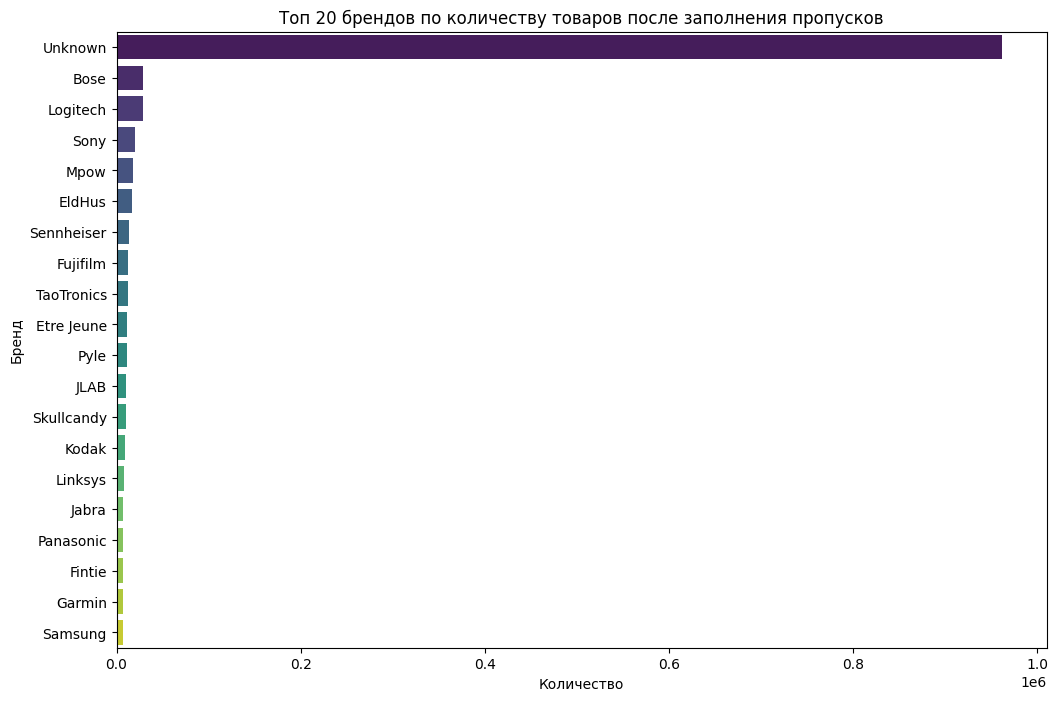

In [20]:
plt.figure(figsize=(12,8))
top_brands = df['brand'].value_counts().head(20)
sns.barplot(x=top_brands.values, y=top_brands.index, palette='viridis')
plt.title('Топ 20 брендов по количеству товаров после заполнения пропусков')
plt.xlabel('Количество')
plt.ylabel('Бренд')
plt.show()

Время время идет, чистим смотрим

Количество взаимодействий на пользователя/на товар

In [31]:
user_interactions = df['user_id'].value_counts().rename('user_interactions')
df = df.merge(user_interactions, on='user_id')

item_interactions = df['item_id'].value_counts().rename('item_interactions')
df = df.merge(item_interactions, on='item_id')

Сколько раз пользователь взаимодействовал с товаром

In [32]:
user_item_counts = df.groupby(['user_id', 'item_id']).size().rename('user_item_count').reset_index()
df = df.merge(user_item_counts, on=['user_id', 'item_id'])

Сред рейтинг по пользователям и товарам

In [33]:
user_mean_rating = df.groupby('user_id')['rating'].mean().rename('user_mean_rating')
df = df.merge(user_mean_rating, on='user_id')

item_mean_rating = df.groupby('item_id')['rating'].mean().rename('item_mean_rating')
df = df.merge(item_mean_rating, on='item_id')

Сколько раз пользователь покупает конкретную категорию

In [34]:
category_columns = [col for col in df.columns if 'category_' in col]
user_category_interactions = df.groupby('user_id')[category_columns].sum().reset_index()

user_category_interactions = user_category_interactions.rename(columns=lambda x: x.replace('category_', 'user_cat_') if 'category_' in x else x)
df = df.merge(user_category_interactions, on='user_id', suffixes=('', '_user_cat'))

брендом? Я люблю макданальс

In [35]:
brand_columns = [col for col in df.columns if 'brand_' in col]
user_brand_interactions = df.groupby('user_id')[brand_columns].sum().reset_index()

user_brand_interactions = user_brand_interactions.rename(columns=lambda x: x.replace('brand_', 'user_brand_') if 'brand_' in x else x)

df = df.merge(user_brand_interactions, on='user_id', suffixes=('', '_user_brand'))

кол-во уникальных пользователей, покупающих товар

In [54]:
item_unique_users = df.groupby('item_id')['user_id'].nunique().rename('item_unique_users')
df = df.merge(item_unique_users, on='item_id')

In [4]:
train_df = df[df.last_watch_dt < 6000].copy()

test_df = df[df.last_watch_dt >= 6000].copy()

In [7]:
test_df.shape

(208747, 11)

In [5]:
only_in_train = np.setdiff1d(train_df.user_id.unique(), test_df.user_id.unique())
only_in_test = np.setdiff1d(test_df.user_id.unique(), train_df.user_id.unique())

count_only_in_one = len(only_in_train) + len(only_in_test)

In [37]:
print(f'only train: {len(only_in_train)}, only test {len(only_in_test)}, only_one:{count_only_in_one}')

only train: 578103, only test 545656, only_one:1123759


In [38]:
len(np.intersect1d(train_df.user_id.unique(),test_df.user_id.unique() ))

33874

In [6]:
train_users = train_df.user_id.unique()
test_users = test_df.user_id.unique()

all_included = np.intersect1d(train_users, test_users)

print('число людей и там и там: ', all_included.shape[0])
print('число людей всего:', train_users.shape[0])

число людей и там и там:  33874
число людей всего: 611977


In [8]:
num_users = len(all_included)

all_included = np.random.choice(all_included, size=num_users, replace=False)

In [9]:
train_df = train_df.loc[train_df.user_id.isin(all_included)].copy()

test_df = test_df.loc[test_df.user_id.isin(all_included)].copy()

assert train_df.last_watch_dt.max() < test_df.last_watch_dt.min()
assert len(train_df.user_id.unique()) == num_users
assert len(test_df.user_id.unique()) == num_users

In [42]:
test_df

,item_id,user_id,rating,timestamp,model_attr,category,brand,year,user_attr,split,last_watch_dt
672949,6446,327016,5.0,2015-11-16,Female,Computers & Accessories,NaN,2015,NaN,2,6000
672950,4910,216101,3.0,2015-11-16,Male,Accessories & Supplies,NaN,2014,NaN,2,6000
672956,4910,353232,5.0,2015-11-16,Male,Accessories & Supplies,NaN,2014,NaN,2,6000
672957,6446,306939,5.0,2015-11-16,Female,Computers & Accessories,NaN,2015,NaN,1,6000
672964,2279,465254,3.0,2015-11-16,Male,Computers & Accessories,NaN,2012,Male,0,6000
...,...,...,...,...,...,...,...,...,...,...,...
1292666,9513,548086,4.0,2018-08-27,Male,Headphones,Mpow,2018,NaN,2,7015
1292751,9315,321394,5.0,2018-08-29,Male,Headphones,NaN,2016,NaN,2,7017
1292843,8239,67472,5.0,2018-09-01,Male,Computers & Accessories,NaN,2015,NaN,2,7020
1292867,9533,210581,5.0,2018-09-04,Male,Computers & Accessories,NaN,2018,NaN,2,7023


In [10]:
train_group = train_df.groupby('user_id').apply(
    lambda x : [(t1, t2, t3) for t1, t2, t3 in sorted(zip(x.item_id,x.model_attr, x.rating), key=lambda x : x[1])]
).reset_index()


test_group = test_df.groupby('user_id').apply(
    lambda x : [(t1, t2, t3) for t1, t2, t3 in sorted(zip(x.item_id, x.model_attr, x.rating), key=lambda x : x[1])]
).reset_index()

test_group.rename({0 : 'test_interactions'}, axis=1, inplace=True)

train_group.rename({0 : 'train_interactions'}, axis=1, inplace=True)

In [176]:
test_group

,user_id,test_interactions
0,7,"[(9046, Male, 5.0)]"
1,211,"[(5940, Female&Male, 5.0)]"
2,233,"[(8425, Female, 5.0)]"
3,250,"[(4181, Female, 2.0)]"
4,269,"[(8385, Female&Male, 5.0), (4419, Male, 5.0)]"
...,...,...
33869,611941,"[(6007, Male, 1.0)]"
33870,611942,"[(5405, Female, 5.0)]"
33871,611952,"[(3403, Female&Male, 4.0)]"
33872,611960,"[(552, Female&Male, 4.0)]"


In [11]:
joined = train_group.merge(test_group)

In [164]:
joined

,user_id,train_interactions,test_interactions
0,7,"[(0, 2.0, Female), (2205, 5.0, Female&Male)]","[(9046, 5.0, Male)]"
1,211,"[(14, 1.0, Female&Male)]","[(5940, 5.0, Female&Male)]"
2,233,"[(14, 5.0, Female&Male)]","[(8425, 5.0, Female)]"
3,250,"[(14, 4.0, Female&Male)]","[(4181, 2.0, Female)]"
4,269,"[(1884, 4.0, Male), (14, 5.0, Female&Male), (1...","[(8385, 5.0, Female&Male), (4419, 5.0, Male)]"
...,...,...,...
33869,611941,"[(3168, 5.0, Female)]","[(6007, 1.0, Male)]"
33870,611942,"[(554, 5.0, Male)]","[(5405, 5.0, Female)]"
33871,611952,"[(3939, 5.0, Male)]","[(3403, 4.0, Female&Male)]"
33872,611960,"[(6328, 5.0, Female&Male)]","[(552, 4.0, Female&Male)]"


In [12]:
import lightgbm
from lightgbm import LGBMRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler

class Model_To_Rating:
    def __init__(self, model):
        self.model = model
        self.trained = False
        
    def fit(self, df,  col='train_interactions'):
        df_exploded = df.explode(col).copy()
        df_exploded['item_id'] = df_exploded[col].apply(lambda x: x[0])
#         df_exploded['timestamp'] = df_exploded[col].apply(lambda x: x[1])
        df_exploded['rating'] = df_exploded[col].apply(lambda x: x[2])
        df_exploded['model_attr'] = df_exploded[col].apply(lambda x: x[1])
        df_exploded = df_exploded.drop(columns=[col])
        
#         scaler = StandardScaler()
    
        X = df_exploded[['user_id', 'item_id']]
#         X = pd.get_dummies(X)
        y = df_exploded['rating']
#         X = scaler.fit_transform(X, y)
#         self.scaler = scaler
        self.model.fit(X, y)
        self.trained = True
        
    def predict(self, df, col='test_interactions'):
        assert self.trained
        df_exploded = df.explode(col).copy()
        df_exploded['item_id'] = df_exploded[col].apply(lambda x: x[0])
#         df_exploded['timestamp'] = df_exploded[col].apply(lambda x: x[1])
#         df_exploded['rating'] = df_exploded[col].apply(lambda x: x[2])
        df_exploded['model_attr'] = df_exploded[col].apply(lambda x: x[1])
        df_exploded = df_exploded.drop(columns=[col])

        X = df_exploded[['user_id', 'item_id']]
        X_ = pd.DataFrame(X)
#         y = df_exploded['rating']
        X = pd.get_dummies(X)
        
        predicted = self.model.predict(X)
        
        X_['predicted_ratings'] = predicted
        return X_

    
    def get_metrics(self, predict):
        mse = mean_squared_error(predict, y)
        r2 = r2_score(predict, y)
        mae = mean_absolute_error(predict, y)
        return mse, r2, mae
    def unexplode_items(self, df):
        result = df.groupby('user_id').agg(
        top_popular_items=('item_id', list),
        predicted_ratings=('predicted_ratings', list)
    ).reset_index()
        return result
    def get_top_k_items(self, row, n, col):
        item_ratings = list(zip(row[col], row['predicted_ratings']))
        top_items = sorted(item_ratings, key=lambda x: x[1], reverse=True)[:n]
        return [item[0] for item in top_items]  # Возвращаем только item_id

            
        
        
        

In [19]:
# top = TopPopularRecs()

# top.fit(joined)

# joined['top_popular_recs'] = top.predict(joined, 100)

model = Model_To_Rating(LGBMRegressor())
model.fit(train_group)



[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000247 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 45392, number of used features: 2
[LightGBM] [Info] Start training from score 4.132160


In [21]:
predict = model.predict(joined, col='top_popular_recs')

a = model.unexplode_items(predict)

joined['sort_items'] = a.apply(lambda row: model.get_top_k_items(row, n=10, col='top_popular_items'), axis=1)

joined


,user_id,train_interactions,test_interactions,top_popular_recs,sort_items
0,7,"[(0, Female, 2.0), (2205, Female&Male, 5.0)]","[(9046, Male, 5.0)]","[(1575, Male), (2279, Male), (2031, Female), (...","[2205, 2129, 2148, 4968, 2031, 2016, 5057, 2, ..."
1,211,"[(14, Female&Male, 1.0)]","[(5940, Female&Male, 5.0)]","[(1575, Male), (2279, Male), (2031, Female), (...","[2205, 2129, 2148, 4968, 2031, 2016, 5057, 2, ..."
2,233,"[(14, Female&Male, 5.0)]","[(8425, Female, 5.0)]","[(1575, Male), (2279, Male), (2031, Female), (...","[2205, 2129, 2148, 4968, 2031, 2016, 5057, 2, ..."
3,250,"[(14, Female&Male, 4.0)]","[(4181, Female, 2.0)]","[(1575, Male), (2279, Male), (2031, Female), (...","[2205, 2129, 2148, 4968, 2031, 2016, 5057, 2, ..."
4,269,"[(175, Female, 5.0), (3561, Female, 5.0), (14,...","[(8385, Female&Male, 5.0), (4419, Male, 5.0)]","[(1575, Male), (2279, Male), (2031, Female), (...","[2205, 2129, 2148, 4968, 2031, 2016, 5057, 2, ..."
...,...,...,...,...,...
33869,611941,"[(3168, Female, 5.0)]","[(6007, Male, 1.0)]","[(1575, Male), (2279, Male), (2031, Female), (...","[468, 557, 1715, 791, 752, 836, 927, 828, 2483..."
33870,611942,"[(554, Male, 5.0)]","[(5405, Female, 5.0)]","[(1575, Male), (2279, Male), (2031, Female), (...","[468, 557, 1715, 791, 752, 836, 927, 828, 2483..."
33871,611952,"[(3939, Male, 5.0)]","[(3403, Female&Male, 4.0)]","[(1575, Male), (2279, Male), (2031, Female), (...","[468, 557, 1715, 791, 752, 836, 927, 828, 2483..."
33872,611960,"[(6328, Female&Male, 5.0)]","[(552, Female&Male, 4.0)]","[(1575, Male), (2279, Male), (2031, Female), (...","[468, 557, 1715, 791, 752, 836, 927, 828, 2483..."


In [25]:
evaluate_recommender(joined, model_preds='sort_items')

{'map': 0.0037594599942671367,
 'mrr': 0.0051035068334472,
 'hr': 0.005874712168624904,
 'ndcg': 0.02881087708132924,
 'recall': 0.024465438445555935}

In [38]:
class Random:
  def __init__(self):
    self.trained = False

  def fit(self,  df, col='train_interactions'):

    items = set()

    for _, row in df.iterrows():
      for item, _ in row[col]:
        items.add(item)

    self.items = items
    self.trained = True

  def predict(self, df, top_n=10):
    assert self.trained == True

    return [np.random.choice(list(self.items), replace=False, size=top_n)] * len(df)





In [40]:
random = Random()

random.fit(joined)

joined['random_items'] = random.predict(joined, top_n=10)

In [146]:
joined

,user_id,train_interactions,test_interactions
0,7,"[(0, 30, 2.0, Female), (2205, 5849, 5.0, Femal...","[(9046, 6240, 5.0, Male)]"
1,211,"[(14, 545, 1.0, Female&Male)]","[(5940, 6144, 5.0, Female&Male)]"
2,233,"[(14, 569, 5.0, Female&Male)]","[(8425, 6170, 5.0, Female)]"
3,250,"[(14, 587, 4.0, Female&Male)]","[(4181, 6179, 2.0, Female)]"
4,269,"[(14, 628, 5.0, Female&Male), (15, 636, 5.0, F...","[(8385, 6130, 5.0, Female&Male), (4419, 6219, ..."
...,...,...,...
33869,611941,"[(3168, 5999, 5.0, Female)]","[(6007, 6214, 1.0, Male)]"
33870,611942,"[(554, 5999, 5.0, Male)]","[(5405, 6046, 5.0, Female)]"
33871,611952,"[(3939, 5999, 5.0, Male)]","[(3403, 6243, 4.0, Female&Male)]"
33872,611960,"[(6328, 5999, 5.0, Female&Male)]","[(552, 6085, 4.0, Female&Male)]"


In [23]:
def ap_metric(gt_items, predictions, topn):

  predictions = predictions[:topn]

  relev = np.isin(predictions, gt_items).astype(int)

  precision_k = np.cumsum(relev) / np.arange(1, len(predictions) + 1)

  ap = (relev * precision_k).sum() / min(topn, len(gt_items))

  return ap

def rr_metric(gt_items, predictions, topn):
    predictions = predictions[:topn]

    for rank, item in enumerate(predictions, start=1):

      if item in gt_items:
        return 1 / rank

    return 0
def ndcg_metric(gt_items, predicted):

    at = len(predicted)
    relevance = np.array([1 if x in predicted else 0 for x in gt_items])
    # DCG uses the relevance of the recommended items
    rank_dcg = dcg(relevance)

    if rank_dcg == 0.0:
        return 0.0

    # IDCG has all relevances to 1 (or the values provided), up to the number of items in the test set that can fit in the list length
    ideal_dcg = dcg(np.sort(relevance)[::-1][:at])

    if ideal_dcg == 0.0:
        return 0.0

    ndcg_ = rank_dcg / ideal_dcg

    return ndcg_


def dcg(scores):
    return np.sum(
        np.divide(np.power(2, scores) - 1, np.log2(np.arange(scores.shape[0], dtype=np.float64) + 2)), dtype=np.float64
    )


def recall_metric(gt_items, predicted):

    n_gt = len(gt_items)
    intersection = len(set(gt_items).intersection(set(predicted)))
    return intersection / n_gt



def hr_metric(gt_items, predictions,topn):

    return any(pred in gt_items for pred in predictions[:topn])

In [24]:
def evaluate_recommender(df, model_preds, gt_col='test_interactions'):

    metric_values = []

    for idx, row in df.iterrows():
        gt_items = [x[0] for x in row[gt_col]]
        predictions = row[model_preds]

        ap = ap_metric(gt_items, predictions, topn=len(gt_items))
        rr = rr_metric(gt_items, predictions, topn=len(gt_items))
        hr = hr_metric(gt_items, predictions, topn=len(gt_items))
        ndcg = ndcg_metric(gt_items, predictions)
        recall = recall_metric(gt_items, predictions)

        metric_values.append((ap, rr, hr, ndcg, recall))

    return {'map': np.mean([x[0] for x in metric_values]),
            'mrr': np.mean([x[1] for x in metric_values]),
            'hr': np.mean([x[2] for x in metric_values]),
           'ndcg' : np.mean([x[3] for x in metric_values]),
           'recall' : np.mean([x[4] for x in metric_values])}

In [44]:
evaluate_recommender(joined, model_preds='random_items')

{'map': 0.0,
 'mrr': 0.0,
 'hr': 0.0,
 'ndcg': 0.0037248497352318304,
 'recall': 0.0036117095425167913}

In [13]:
class TopPopularRecs:
    def __init__(self):
        self.trained = False
        
    def fit(self, df, col='train_interactions'):
        counts = {}
        for _, row in df.iterrows():
            for item_id, model_attr, *_ in row[col]:  
                if (item_id, model_attr) in counts:
                    counts[(item_id, model_attr)] += 1
                else:
                    counts[(item_id, model_attr)] = 1

        # Сортируем по популярности
        sorted_counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)
        self.recommendation = [x[0] for x in sorted_counts]  
        self.trained = True
        
    def predict(self, df, topn):
        assert self.trained 
        return [self.recommendation[:topn]] * len(df)

In [14]:
top = TopPopularRecs()

top.fit(joined)

joined['top_popular_recs'] = top.predict(joined, 100)

In [15]:
joined

,user_id,train_interactions,test_interactions,top_popular_recs
0,7,"[(0, Female, 2.0), (2205, Female&Male, 5.0)]","[(9046, Male, 5.0)]","[(1575, Male), (2279, Male), (2031, Female), (..."
1,211,"[(14, Female&Male, 1.0)]","[(5940, Female&Male, 5.0)]","[(1575, Male), (2279, Male), (2031, Female), (..."
2,233,"[(14, Female&Male, 5.0)]","[(8425, Female, 5.0)]","[(1575, Male), (2279, Male), (2031, Female), (..."
3,250,"[(14, Female&Male, 4.0)]","[(4181, Female, 2.0)]","[(1575, Male), (2279, Male), (2031, Female), (..."
4,269,"[(175, Female, 5.0), (3561, Female, 5.0), (14,...","[(8385, Female&Male, 5.0), (4419, Male, 5.0)]","[(1575, Male), (2279, Male), (2031, Female), (..."
...,...,...,...,...
33869,611941,"[(3168, Female, 5.0)]","[(6007, Male, 1.0)]","[(1575, Male), (2279, Male), (2031, Female), (..."
33870,611942,"[(554, Male, 5.0)]","[(5405, Female, 5.0)]","[(1575, Male), (2279, Male), (2031, Female), (..."
33871,611952,"[(3939, Male, 5.0)]","[(3403, Female&Male, 4.0)]","[(1575, Male), (2279, Male), (2031, Female), (..."
33872,611960,"[(6328, Female&Male, 5.0)]","[(552, Female&Male, 4.0)]","[(1575, Male), (2279, Male), (2031, Female), (..."


In [47]:
evaluate_recommender(joined, model_preds='top_popular_recs')

{'map': 0.05306414480631943,
 'mrr': 0.05661513116208339,
 'hr': 0.05778735268026866,
 'ndcg': 0.14039268306085628,
 'recall': 0.1347516157647953}

In [49]:
class TopWeightedPopular:
    def __init__(self, min_window):
        super().__init__()
        self.min_window = min_window
        self.trained = False
        
    def fit(self, df, col='train_interactions'):
        window_size = 30 * self.min_window
        counts = {}
        for _, row in df.iterrows():
            for item, time in row[col]:
                if time >= 6500 - window_size :
                    if item in counts:
                        counts[item] += 1
                    else:
                        counts[item] = 1
        top_pop_counts_per_last_month = sorted(counts.items(), key=lambda x :x[1], reverse=True)
        
        self.fit_rec = [x[0] for x in top_pop_counts_per_last_month]
        self.trained = True
        
    def predict(self, df, topn):
        assert self.trained
        
        self.recomend = [self.fit_rec[:topn]] * len(df)
        return self.recomend
        
        
                        
        
        
        
        

In [50]:
maps = []

mrrs = []

hrs = []

ndcgs = []

recalls = []

for w_size in range(1, 5):
    topn = TopWeightedPopular(min_window=w_size)
    topn.fit(joined)
    
    predict = topn.predict(joined, topn=5)
    
    joined[f'window_{w_size}_rec'] = predict
    
    map, mrr, hr, ndcg, recall = evaluate_recommender(joined, f'window_{w_size}_rec').values()
    
    maps.append(map)
    mrrs.append(mrr)
    hrs.append(hr)
    ndcgs.append(ndcg)
    recalls.append(recall)

    

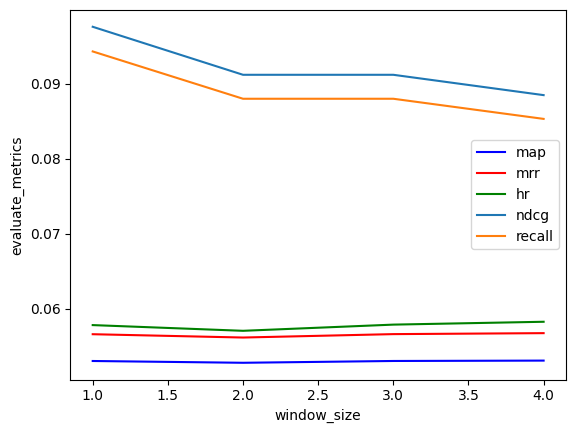

In [53]:
x = np.arange(1, 5)

plt.plot(x, maps, label='map', color='blue')
plt.plot(x, mrrs, label='mrr', color='red')
plt.plot(x, hrs, label='hr', color='green')
plt.plot(x, ndcgs, label='ndcg')
plt.plot(x, recalls, label='recall')

plt.xlabel('window_size')
plt.ylabel('evaluate_metrics')
plt.legend()

In [54]:
df = joined.copy()

ks = np.arange(1, 100)

maps = []

mrrs = []

hrs = []

ndcgs = []

recalls = []

for k in ks:
    df[f'predict_{k}'] = top.predict(df, topn=k)
    
    map, mrr, hr, ndcg, recall = evaluate_recommender(df, f'predict_{k}').values()
    
    maps.append(map)
    mrrs.append(mrr)
    hrs.append(hr)
    ndcgs.append(ndcg)
    recalls.append(recall)

    

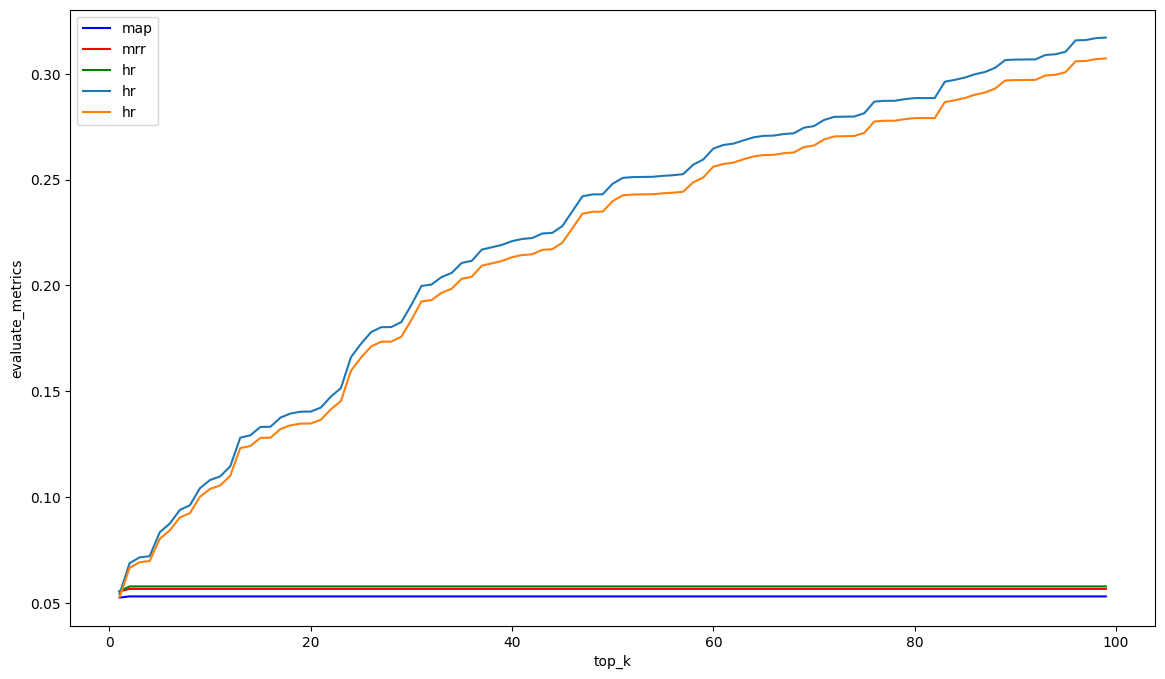

In [55]:
plt.figure(figsize=(14, 8))

plt.plot(ks, maps, label='map', color='blue')
plt.plot(ks, mrrs, label='mrr', color='red')
plt.plot(ks, hrs, label='hr', color='green')
plt.plot(ks, ndcgs, label='hr')
plt.plot(ks, recalls, label='hr')

plt.xlabel('top_k')
plt.ylabel('evaluate_metrics')
plt.legend()

In [204]:
from scipy.sparse import csr_matrix
from implicit.als import AlternatingLeastSquares
from implicit.bpr import BayesianPersonalizedRanking
from sklearn.preprocessing import LabelEncoder
from tqdm.auto import tqdm

class Implicit_Als:
    def __init__(self, model):
        self.model = model
        self.trained = False
    def fit(self, train_df):
        self.user_encoder = LabelEncoder()
        self.item_encoder = LabelEncoder()
        self.user_encoder.fit(train_df.user_id)
        self.item_encoder.fit(train_df.item_id)
        
        self.train_ratings = self.encode_table(train_df, ['user_id', 'item_id'])
        self.model.fit(self.train_ratings)
        self.trained = True
    def predict(self, test_df, top_k=10):
        if not self.trained:
            raise ValueError('model is not trained yet')
            
        user_to_predict = test_df.user_id
        encoded_users = self.user_encoder.transform(user_to_predict)
        user_recs = self.model.recommend(
            encoded_users, self.train_ratings[encoded_users], 
            N=top_k, filter_already_liked_items=True
        )[0]
        
        recs = [self.item_encoder.inverse_transform(x) for x in user_recs]
        return recs
    
    def encode_table(
        self,
        df,
        axis_names,
    ):
        user_ids = self.user_encoder.transform(df[axis_names[0]])
        item_ids = self.item_encoder.transform(df[axis_names[1]])

        matrix_shape = len(self.user_encoder.classes_), len(self.item_encoder.classes_)

        sparse = csr_matrix((np.ones(len(user_ids)), (user_ids, item_ids)), shape=matrix_shape, dtype=np.float32)

        return sparse
       
            
        

In [205]:
als = AlternatingLeastSquares(factors=32, iterations=3, 
                              regularization=0.01, calculate_training_loss=True )
als_recommender = Implicit_Als(als)
als_recommender.fit(train_df)

/home/fltww/anaconda3/envs/ML/lib/python3.7/site-packages/implicit/cpu/als.py:95: RuntimeWarning: OpenBLAS is configured to use 8 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()


TypeError: unhashable type: 'numpy.ndarray'

In [71]:
predict_als = als_recommender.predict(joined)

joined['als_rec'] = predict_als
joined

,user_id,train_interactions,test_interactions,random_items,top_popular_recs,window_1_rec,window_2_rec,window_3_rec,window_4_rec,als_rec,bpr_rec
0,440,"[(2593, 5097), (3460, 5883)]","[(5897, 6937)]","[2797, 3164, 8011, 6687, 6382, 1531, 2494, 248...","[7780, 2031, 2279, 1575, 274, 1124, 468, 1605,...","[7780, 2031, 5054, 6378, 6210]","[7780, 6378, 2031, 5054, 162]","[7780, 2031, 5054, 6378, 162]","[7780, 2031, 5795, 162, 5054]","[4718, 7922, 2129, 3101, 111, 259, 4808, 6210,...","[2279, 1659, 7057, 3524, 3597, 5407, 593, 4834..."
1,545,"[(2237, 6160)]","[(1875, 6567)]","[2797, 3164, 8011, 6687, 6382, 1531, 2494, 248...","[7780, 2031, 2279, 1575, 274, 1124, 468, 1605,...","[7780, 2031, 5054, 6378, 6210]","[7780, 6378, 2031, 5054, 162]","[7780, 2031, 5054, 6378, 162]","[7780, 2031, 5795, 162, 5054]","[6689, 2129, 5940, 2, 5041, 111, 2355, 5054, 1...","[1659, 2279, 3524, 7057, 3597, 4834, 5407, 725..."
2,822,"[(2486, 5337)]","[(87, 6781)]","[2797, 3164, 8011, 6687, 6382, 1531, 2494, 248...","[7780, 2031, 2279, 1575, 274, 1124, 468, 1605,...","[7780, 2031, 5054, 6378, 6210]","[7780, 6378, 2031, 5054, 162]","[7780, 2031, 5054, 6378, 162]","[7780, 2031, 5795, 162, 5054]","[5884, 1861, 43, 5940, 2, 2483, 1715, 4808, 25...","[2279, 1659, 3524, 7057, 7251, 5407, 4834, 441..."
3,847,"[(6356, 5774)]","[(2237, 6688)]","[2797, 3164, 8011, 6687, 6382, 1531, 2494, 248...","[7780, 2031, 2279, 1575, 274, 1124, 468, 1605,...","[7780, 2031, 5054, 6378, 6210]","[7780, 6378, 2031, 5054, 162]","[7780, 2031, 5054, 6378, 162]","[7780, 2031, 5795, 162, 5054]","[7770, 619, 1659, 1605, 4730, 5041, 4718, 1875...","[2279, 1659, 3524, 7057, 4834, 5407, 7251, 271..."
4,858,"[(5273, 5862)]","[(6210, 6660)]","[2797, 3164, 8011, 6687, 6382, 1531, 2494, 248...","[7780, 2031, 2279, 1575, 274, 1124, 468, 1605,...","[7780, 2031, 5054, 6378, 6210]","[7780, 6378, 2031, 5054, 162]","[7780, 2031, 5054, 6378, 162]","[7780, 2031, 5795, 162, 5054]","[4718, 1861, 43, 3442, 7922, 3106, 1886, 6726,...","[1659, 2279, 3524, 7057, 2719, 3597, 4834, 593..."
...,...,...,...,...,...,...,...,...,...,...,...
15777,973016,"[(5071, 6499)]","[(6689, 6514)]","[2797, 3164, 8011, 6687, 6382, 1531, 2494, 248...","[7780, 2031, 2279, 1575, 274, 1124, 468, 1605,...","[7780, 2031, 5054, 6378, 6210]","[7780, 6378, 2031, 5054, 162]","[7780, 2031, 5054, 6378, 162]","[7780, 2031, 5795, 162, 5054]","[4718, 1659, 2, 619, 1875, 43, 259, 2237, 468,...","[2279, 1659, 3524, 7057, 7251, 3597, 4834, 441..."
15778,973069,"[(7904, 6499)]","[(1395, 6794)]","[2797, 3164, 8011, 6687, 6382, 1531, 2494, 248...","[7780, 2031, 2279, 1575, 274, 1124, 468, 1605,...","[7780, 2031, 5054, 6378, 6210]","[7780, 6378, 2031, 5054, 162]","[7780, 2031, 5054, 6378, 162]","[7780, 2031, 5795, 162, 5054]","[259, 619, 2486, 5795, 4718, 43, 7770, 1670, 1...","[1659, 2279, 3524, 7057, 4834, 7251, 3597, 447..."
15779,973071,"[(5884, 6499)]","[(7780, 6745)]","[2797, 3164, 8011, 6687, 6382, 1531, 2494, 248...","[7780, 2031, 2279, 1575, 274, 1124, 468, 1605,...","[7780, 2031, 5054, 6378, 6210]","[7780, 6378, 2031, 5054, 162]","[7780, 2031, 5054, 6378, 162]","[7780, 2031, 5795, 162, 5054]","[5897, 2486, 5054, 7770, 1780, 1861, 1124, 579...","[1659, 2279, 3524, 7057, 3597, 1743, 5140, 725..."
15780,973172,"[(521, 6499)]","[(4718, 6931)]","[2797, 3164, 8011, 6687, 6382, 1531, 2494, 248...","[7780, 2031, 2279, 1575, 274, 1124, 468, 1605,...","[7780, 2031, 5054, 6378, 6210]","[7780, 6378, 2031, 5054, 162]","[7780, 2031, 5054, 6378, 162]","[7780, 2031, 5795, 162, 5054]","[4718, 4730, 7770, 7256, 2031, 619, 3995, 274,...","[2279, 1659, 7057, 3524, 4834, 7251, 3597, 593..."


In [72]:
evaluate_recommender(joined, model_preds='als_rec')

{'map': 0.006199045325898703,
 'mrr': 0.007065010771765302,
 'hr': 0.007540235711570143,
 'ndcg': 0.04289708361356819,
 'recall': 0.040573649305115526}

In [67]:
bpr = BayesianPersonalizedRanking(
    iterations=7,
    factors=16,
    regularization=0.001,
    learning_rate=0.001,
)
bpr_recommender = Implicit_Als(bpr)
bpr_recommender.fit(train_df)

  0%|          | 0/7 [00:00<?, ?it/s]

In [68]:
preds = bpr_recommender.predict(joined, top_k=10)

joined['bpr_rec'] = preds

evaluate_recommender(joined, model_preds='bpr_rec')

{'map': 0.003729635731283178,
 'mrr': 0.004108055590757402,
 'hr': 0.004498796096819161,
 'ndcg': 0.012225334386597772,
 'recall': 0.01163773074810966}

In [ ]:
from itertools import product

factors = [20, 50, 100]
regularizations = [0.001, 0.01, 0.1]
iterations = [10, 30, 50]

best_model = None
best_score = -1
dfff = joined.copy()
for f, reg, it in product(factors, regularizations, iterations):
    als = AlternatingLeastSquares(factors=f, iterations=it, 
                                  regularization=reg, calculate_training_loss=True)
    als_recommender = Implicit_Als(als)
    als_recommender.fit(train_df)
    predict = als_recommender.predict(dfff)
    dfff[f'als with factors{f} reg{reg} it{it}'] = predict
    score = evaluate_recommender(dfff, model_preds=f'als with factors{f} reg{reg} it{it}').get('ndcg')  
    print(f"factors: {f}, reg: {reg}, iterations: {it}, score: {score}")
    
    if score > best_score:
        best_score = score
        best_model = als_recommender

print(f"Лучшие параметры: factors={best_model.factors}, regularization={best_model.regularization}, iterations={best_model.iterations}")

  0%|          | 0/10 [00:00<?, ?it/s]

factors: 20, reg: 0.001, iterations: 10, score: 0.04889587798865425


  0%|          | 0/30 [00:00<?, ?it/s]

factors: 20, reg: 0.001, iterations: 30, score: 0.050159240914034765


  0%|          | 0/50 [00:00<?, ?it/s]

...

  0%|          | 0/50 [00:00<?, ?it/s]

factors: 50, reg: 0.01, iterations: 50, score: 0.03406033135607073


  0%|          | 0/10 [00:00<?, ?it/s]

factors: 50, reg: 0.1, iterations: 10, score: 0.03319702937494387


  0%|          | 0/30 [00:00<?, ?it/s]

SyntaxError: invalid syntax (1864368497.py, line 1)